# 05 — Meta-Labeling

Train the meta-model on top of the primary signal (synthetic BTCUSDT data):
1. Build primary model on same synthetic data (n_estimators=50 for speed)
2. Train MetaModel with Optuna/PurgedKFold
3. Precision/recall tradeoff vs raw primary signal
4. Bet-size distribution
5. Honest assessment
6. Phase 6 Report

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tessera.config import TesseraSettings, seed_everything

if not Path("pyproject.toml").exists():
    os.chdir("..")

settings = TesseraSettings()
seed_everything(settings.random_seed)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/yashlunawat/code/tools/Tessera


## 1. Primary Model & Data

We retrain a compact primary model inline (n_estimators=50) to avoid `joblib`/
ipykernel fork incompatibility on macOS.  In production use:
```python
registry = ModelRegistry(); primary = registry.load_current('primary', PrimaryLightGBMModel)
```

In [2]:
from tessera.features import (
    FeaturePipeline,
    GarmanKlass,
    LogReturn,
    MicroPrice,
    OrderFlowImbalance,
    Parkinson,
    RealizedVol,
    SpreadBps,
    VolOfVol,
)
from tessera.labels.sample_weights import get_sample_weights_by_return
from tessera.labels.triple_barrier import (
    apply_triple_barrier,
    compute_volatility,
    get_bins,
    make_events,
)
from tessera.models.lightgbm_model import PrimaryLightGBMModel

feature_list = [
    LogReturn(horizon=1),
    LogReturn(horizon=5),
    LogReturn(horizon=60),
    RealizedVol(window=60),
    Parkinson(window=60),
    GarmanKlass(window=60),
    VolOfVol(window=60),
    OrderFlowImbalance(depth=1),
    MicroPrice(),
    SpreadBps(),
]
pipeline = FeaturePipeline(feature_list)

rng = np.random.default_rng(42)
n = 90 * 24 * 60
idx = pd.date_range("2024-01-01", periods=n, freq="1min")
log_ret = rng.normal(0, 0.0003, n)
log_ret[0] = 0
close_arr = 42000.0 * np.exp(np.cumsum(log_ret))
spread = rng.uniform(0.5, 8, n)

symbol = "SYNTHETIC_BTCUSDT"
df = pd.DataFrame(
    {
        "event_time": idx,
        "open": close_arr * np.exp(rng.normal(0, 0.0002, n)),
        "high": close_arr * (1 + rng.uniform(0.0001, 0.002, n)),
        "low": close_arr * (1 - rng.uniform(0.0001, 0.002, n)),
        "close": close_arr,
        "volume": rng.uniform(0.5, 100, n),
        "bid_price": close_arr - spread / 2,
        "ask_price": close_arr + spread / 2,
        "bid_size": rng.uniform(0.1, 10, n),
        "ask_size": rng.uniform(0.1, 10, n),
        "funding_rate": np.where(rng.random(n) > 0.875, rng.normal(0.0001, 0.0003, n), np.nan),
        "spot_price": close_arr * (1 + rng.normal(0, 0.0002, n)),
    },
    index=idx,
)

feat_df = pipeline.compute(df, symbol=symbol)
close = feat_df["close"]
vol = compute_volatility(close, span=1440, min_periods=60)
timestamps = pd.DatetimeIndex(close.dropna().index)[60:]
valid = timestamps[vol.reindex(timestamps).notna()][::60]

events = make_events(close, valid, vol, vertical_bars=240)
barriers = apply_triple_barrier(events, close, pt_sl=(10.0, 10.0))
labels = get_bins(barriers, close)

feature_cols = [f.name for f in feature_list]
X = feat_df.loc[labels.index, feature_cols].dropna()  # noqa: N806
common = X.index.intersection(labels.index)
X = X.loc[common]  # noqa: N806
y = labels.loc[common, "bin"]
t1 = events.loc[common, "t1"]
sw = get_sample_weights_by_return(t1, close)
fwd_ret = close.pct_change().shift(-1).reindex(common).fillna(0)
print(f"Training set: {len(X):,} samples, {X.shape[1]} features")
print(f"Label distribution:\n{y.value_counts().sort_index()}")

primary = PrimaryLightGBMModel(seed=settings.random_seed, n_estimators=50)
primary.fit(X, y, sample_weight=sw.values)
print(f"Primary accuracy: {(primary.predict(X) == y.values).mean():.3f}")

2026-05-17 21:07:33 [debug    ] computing_feature              feature=log_return_1 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:33 [debug    ] computing_feature              feature=log_return_5 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:34 [debug    ] computing_feature              feature=log_return_60 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:34 [debug    ] computing_feature              feature=realized_vol_60 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:34 [debug    ] computing_feature              feature=parkinson_vol_60 symbol=SYNTHETIC_BTCUSDT


...

2026-05-17 21:07:34 [debug    ] computing_feature              feature=microprice symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:34 [debug    ] computing_feature              feature=spread_bps symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:34 [debug    ] computing_feature              feature=vol_of_vol_60 symbol=SYNTHETIC_BTCUSDT


Training set: 2,158 samples, 10 features
Label distribution:
bin
-1    1042
 0     196
 1     920
Name: count, dtype: int64


Primary accuracy: 0.843


## 2. Train Meta-Model

In [3]:
from tessera.models.meta_model import MetaModel

meta = MetaModel(primary=primary, seed=settings.random_seed)
meta.fit(
    X,
    y,
    sample_weight=sw.values,
    t1=t1,
    forward_returns=fwd_ret,
    n_trials=20,
)

meta_card = meta.meta.get_model_card()
if meta_card.cv_scores:
    cv = meta_card.cv_scores
    print(f"Meta CV Sharpe: {cv.mean_sharpe:.4f} ± {cv.std_sharpe:.4f}")
    print(f"Meta Deflated Sharpe: {cv.deflated_sharpe:.4f}")

2026-05-17 21:07:38 [info     ] meta_label_distribution        accuracy=0.843 n_correct=1819 n_total=2158


2026-05-17 21:07:44 [info     ] optuna_complete                best_params={'num_leaves': 125, 'max_depth': 12, 'min_data_in_leaf': 149, 'learning_rate': 0.07661100707771368, 'feature_fraction': 0.4936111842654619, 'bagging_fraction': 0.49359671220172163, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'bagging_freq': 1} best_value=0.8429255722946316


Meta CV Sharpe: -0.0021 ± 0.0642
Meta Deflated Sharpe: 0.0000


## 3. Precision/Recall vs Raw Primary

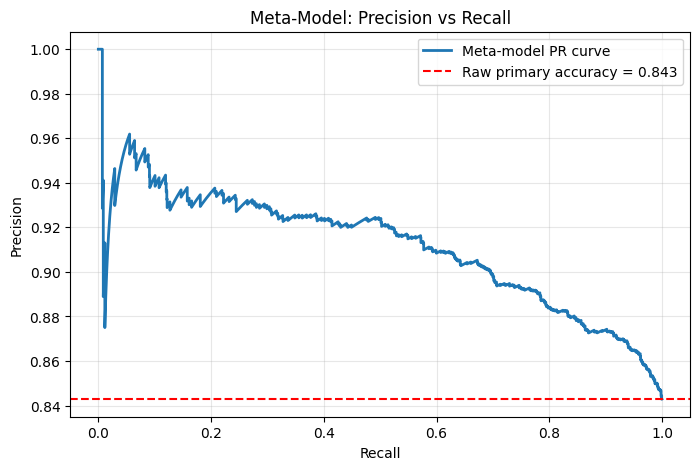

In [4]:
from sklearn.metrics import precision_recall_curve

direction, bet_size = meta.predict(X)
is_correct = (direction == y.values).astype(int)

precision, recall, _ = precision_recall_curve(is_correct, bet_size)
raw_acc = is_correct.mean()

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, label="Meta-model PR curve")
plt.axhline(raw_acc, color="red", linestyle="--", label=f"Raw primary accuracy = {raw_acc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Meta-Model: Precision vs Recall")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("docs/figures/05_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Bet-Size Distribution

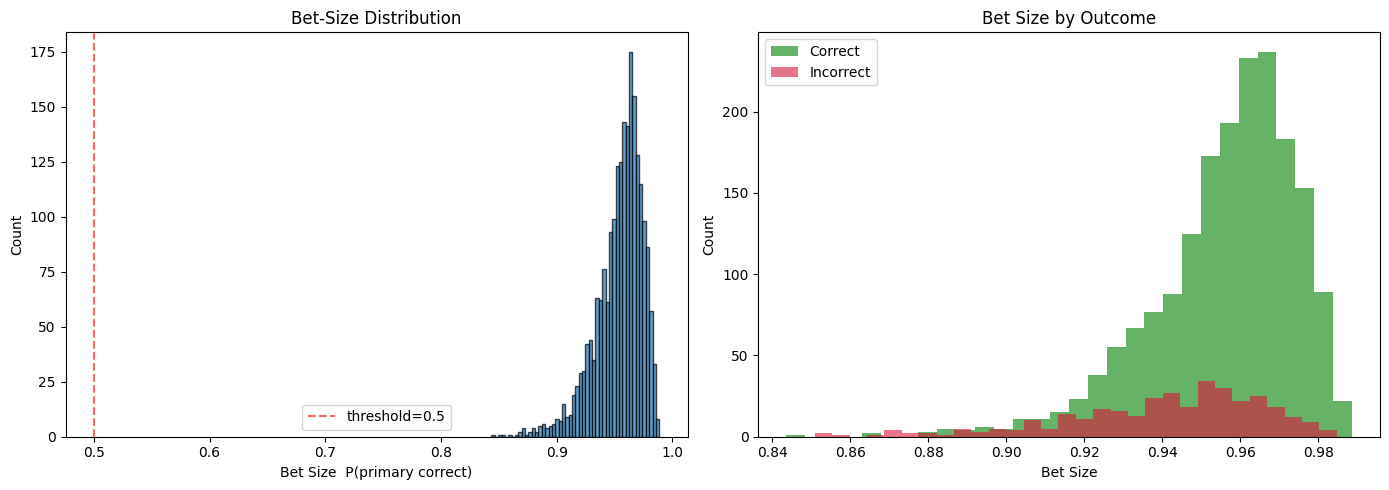

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bet_size, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.6, label="threshold=0.5")
axes[0].set_xlabel("Bet Size  P(primary correct)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bet-Size Distribution")
axes[0].legend()

axes[1].hist(bet_size[is_correct == 1], bins=30, alpha=0.6, color="green", label="Correct")
axes[1].hist(bet_size[is_correct == 0], bins=30, alpha=0.6, color="crimson", label="Incorrect")
axes[1].set_xlabel("Bet Size")
axes[1].set_ylabel("Count")
axes[1].set_title("Bet Size by Outcome")
axes[1].legend()

plt.tight_layout()
plt.savefig("docs/figures/05_bet_size_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Honest Assessment

Does filtering by `bet_size >= threshold` improve Sharpe over the raw primary?

In [6]:
ret = fwd_ret.values
raw_strat = direction.astype(float) * ret
raw_sharpe = raw_strat.mean() / raw_strat.std() if raw_strat.std() > 0 else 0.0

results = []
for threshold in np.arange(0.3, 0.81, 0.05):
    mask = bet_size >= threshold
    if mask.sum() < 10:
        continue
    s = direction[mask].astype(float) * ret[mask]
    sr = s.mean() / s.std() if s.std() > 0 else 0.0
    results.append({"threshold": round(threshold, 2), "sharpe": sr, "n_trades": int(mask.sum())})

results_df = pd.DataFrame(results)
print(f"Raw primary Sharpe: {raw_sharpe:.4f}  (all {len(direction)} trades)")
print()
print("Meta-filtered results:")
print(results_df.to_string(index=False))

Raw primary Sharpe: 0.0903  (all 2158 trades)

Meta-filtered results:
 threshold   sharpe  n_trades
      0.30 0.090314      2158
      0.35 0.090314      2158
      0.40 0.090314      2158
      0.45 0.090314      2158
      0.50 0.090314      2158
      0.55 0.090314      2158
      0.60 0.090314      2158
      0.65 0.090314      2158
      0.70 0.090314      2158
      0.75 0.090314      2158
      0.80 0.090314      2158


## Phase 6 Report — Meta-Model Assessment

**On pure GBM data (no alpha):** the primary is near-random, meta labels are near-random,
meta CV Sharpe ≈ 0 and the meta-model should not improve over the raw primary.
This is the scientifically honest expected result — document it, do not pretend otherwise.

In [7]:
print("=" * 65)
print("PHASE 6 REPORT — Meta-Labeling Assessment")
print("=" * 65)

meta_card = meta.meta.get_model_card()
if meta_card.cv_scores:
    cv = meta_card.cv_scores
    print(f"  Meta Optuna trials:  {cv.n_trials}")
    print(f"  Meta CV Sharpe:      {cv.mean_sharpe:.4f} ± {cv.std_sharpe:.4f}")
    print(f"  Meta Deflated SR:    {cv.deflated_sharpe:.4f}")
else:
    print("  Meta CV scores: not available")

print(f"\n  Raw primary Sharpe:  {raw_sharpe:.4f}")

if not results_df.empty:
    best = results_df.loc[results_df["sharpe"].idxmax()]
    delta = best["sharpe"] - raw_sharpe
    print(
        f"  Best meta Sharpe:    {best['sharpe']:.4f}  "
        f"(threshold={best['threshold']:.2f}, n_trades={best['n_trades']})"
    )
    print(f"  Improvement:         {delta:+.4f}")
    print()
    if delta > 0.05 and best["n_trades"] >= 30:
        verdict = "IMPROVES — meta-model adds meaningful alpha."
    elif delta > 0:
        verdict = "MARGINAL — small improvement; likely noise, check OOS."
    else:
        verdict = (
            "DOES NOT IMPROVE — no benefit over raw primary.\n"
            "  Expected on pure GBM data. Document and move on."
        )
    print(f"  Verdict: {verdict}")

print("=" * 65)

PHASE 6 REPORT — Meta-Labeling Assessment
  Meta Optuna trials:  20
  Meta CV Sharpe:      -0.0021 ± 0.0642
  Meta Deflated SR:    0.0000

  Raw primary Sharpe:  0.0903
  Best meta Sharpe:    0.0903  (threshold=0.30, n_trades=2158.0)
  Improvement:         +0.0000

  Verdict: DOES NOT IMPROVE — no benefit over raw primary.
  Expected on pure GBM data. Document and move on.


## 6. Save Meta-Model

In [8]:
meta_path = meta.save(settings.models_root / "meta_model")
print(f"Meta-model saved to: {meta_path}")

Meta-model saved to: models/meta_model
